# Task 4 · Email / SMS Spam Detection with Machine Learning
**Objective:** Build an NLP binary classifier that separates **spam** from legitimate (**ham**) messages.

**Dataset:** SMS Spam Collection (Kaggle: *SMS Spam Collection Dataset* by UCI ML, file `spam.csv`; also on the UCI repository).
Download it and place `spam.csv` in the same folder as this notebook.

**Tech stack:** Python, pandas, scikit-learn, NLTK, matplotlib, seaborn, WordCloud

## 1. Setup: imports and NLTK resources

In [2]:
import re
import string
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# Download stopwords list (only needed once)
nltk.download('stopwords', quiet=True)

sns.set_style('whitegrid')
RANDOM_STATE = 42

## 2. Data loading

In [3]:
# The Kaggle file is latin-1 encoded and has junk extra columns
df = pd.read_csv('spam.csv', encoding='latin-1')
df = df[['v1', 'v2']]                       # keep only label + text
df.columns = ['label', 'message']           # rename for clarity

print('Shape:', df.shape)
df.head()

Shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
# Basic data quality checks
print(df.info())
print('\nMissing values:\n', df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

# Drop exact duplicates so the same message cannot appear in both train and test
df = df.drop_duplicates().reset_index(drop=True)
print('Shape after removing duplicates:', df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 541.4 KB
None

Missing values:
 label      0
message    0
dtype: int64

Duplicate rows: 403
Shape after removing duplicates: (5169, 2)


## 3. Class distribution check (spam vs. ham)

       Count  Percentage (%)
label                       
ham     4516           87.37
spam     653           12.63


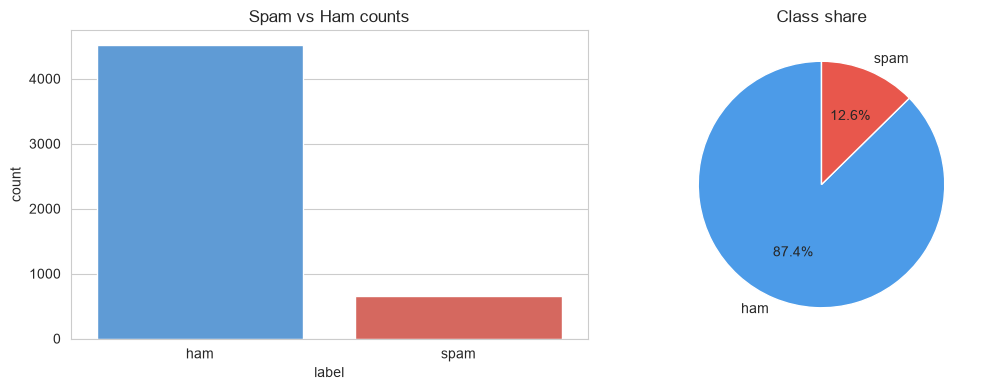

In [5]:
counts = df['label'].value_counts()
percent = df['label'].value_counts(normalize=True) * 100
dist = pd.DataFrame({'Count': counts, 'Percentage (%)': percent.round(2)})
print(dist)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x='label', data=df, palette=['#4C9BE8', '#E8574C'], ax=ax[0])
ax[0].set_title('Spam vs Ham counts')
ax[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
          colors=['#4C9BE8', '#E8574C'], startangle=90)
ax[1].set_title('Class share')
plt.tight_layout(); plt.show()

**Observation:** The dataset is **imbalanced**: ham messages far outnumber spam. So plain accuracy can be misleading
(a model that always predicts "ham" would already score ~87%). That is why we also look at precision, recall and F1.

## 4. Text preprocessing pipeline
Steps: lowercase → remove punctuation → remove stopwords → stemming.

In [6]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    """Clean one message and return the cleaned string."""
    text = text.lower()                                              # 1. lowercase
    text = re.sub(r'http\S+|www\S+', ' ', text)                      # (extra) strip URLs
    text = text.translate(str.maketrans('', '', string.punctuation)) # 2. remove punctuation
    text = re.sub(r'\d+', ' ', text)                                 # (extra) remove digits
    text = re.sub(r'[^a-z\s]', ' ', text)                            # (extra) keep only plain letters (drops encoding junk like å)
    tokens = text.split()                                            # simple whitespace tokenizing
    tokens = [w for w in tokens if w not in stop_words]              # 3. remove stopwords
    tokens = [stemmer.stem(w) for w in tokens]                       # 4. stemming
    return ' '.join(tokens)

# Quick demo on one message
sample = df['message'][2]
print('Original :', sample)
print('Cleaned  :', preprocess_text(sample))

Original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Cleaned  : free entri wkli comp win fa cup final tkt st may text fa receiv entri questionstd txt ratetc appli


In [7]:
df['clean_message'] = df['message'].apply(preprocess_text)

# Encode labels: ham = 0, spam = 1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})
df[['label', 'message', 'clean_message']].head()

,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


## 5. Feature extraction with TF-IDF
**What does TF-IDF measure?**

TF-IDF (*Term Frequency – Inverse Document Frequency*) gives each word a weight showing how **important** it is to a message relative to the whole collection.

- **TF (term frequency)** = how often a word appears in a message. A word that appears many times in one message is probably relevant to it.
- **IDF (inverse document frequency)** = `log(total messages / messages containing the word)`. Words that appear in almost every message (like "get" or "call") get a *low* weight, while rare, distinctive words (like "winner" or "prize") get a *high* weight.
- **TF-IDF = TF × IDF.** A word scores high only if it is frequent in *this* message **and** rare across *other* messages.

This is better than simple word counts because it down-weights common filler words and highlights the words that actually discriminate spam from ham.

## 6. Train / test split

In [8]:
X = df['clean_message']
y = df['label_num']

# stratify=y keeps the same spam/ham ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print('Train size:', X_train.shape[0], '| Test size:', X_test.shape[0])
print('Spam % in train:', round(y_train.mean() * 100, 2))
print('Spam % in test :', round(y_test.mean() * 100, 2))

Train size: 4135 | Test size: 1034
Spam % in train: 12.62
Spam % in test : 12.67


In [9]:
# Fit TF-IDF on TRAINING data only (avoids data leakage), then transform both sets
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('TF-IDF matrix shape (train):', X_train_tfidf.shape)

TF-IDF matrix shape (train): (4135, 5000)


## 7. Model training
We train three classifiers: **Multinomial Naive Bayes** (required), **Logistic Regression** and **Linear SVM** (alternatives).

In [10]:
models = {
    'Multinomial Naive Bayes': MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced',
                                              random_state=RANDOM_STATE),
    'Linear SVM': LinearSVC(class_weight='balanced', random_state=RANDOM_STATE),
}

predictions = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    predictions[name] = model.predict(X_test_tfidf)
    print(f'Trained: {name}')

Trained: Multinomial Naive Bayes
Trained: Logistic Regression
Trained: Linear SVM


## 8. Evaluation: accuracy, precision, recall, F1, confusion matrix

In [11]:
results = []
for name, y_pred in predictions.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df

,Accuracy,Precision,Recall,F1-score
Model,,,,
Multinomial Naive Bayes,0.9816,0.9746,0.8779,0.9237
Logistic Regression,0.9729,0.8815,0.9084,0.8947
Linear SVM,0.9807,0.9370,0.9084,0.9225


In [12]:
# Detailed report for each model
for name, y_pred in predictions.items():
    print('=' * 60)
    print(name)
    print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

Multinomial Naive Bayes
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       903
        Spam       0.97      0.88      0.92       131

    accuracy                           0.98      1034
   macro avg       0.98      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034

Logistic Regression
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.98       903
        Spam       0.88      0.91      0.89       131

    accuracy                           0.97      1034
   macro avg       0.93      0.95      0.94      1034
weighted avg       0.97      0.97      0.97      1034

Linear SVM
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       903
        Spam       0.94      0.91      0.92       131

    accuracy                           0.98      1034
   macro avg       0.96      0.95      0.96      1034
weighted avg       

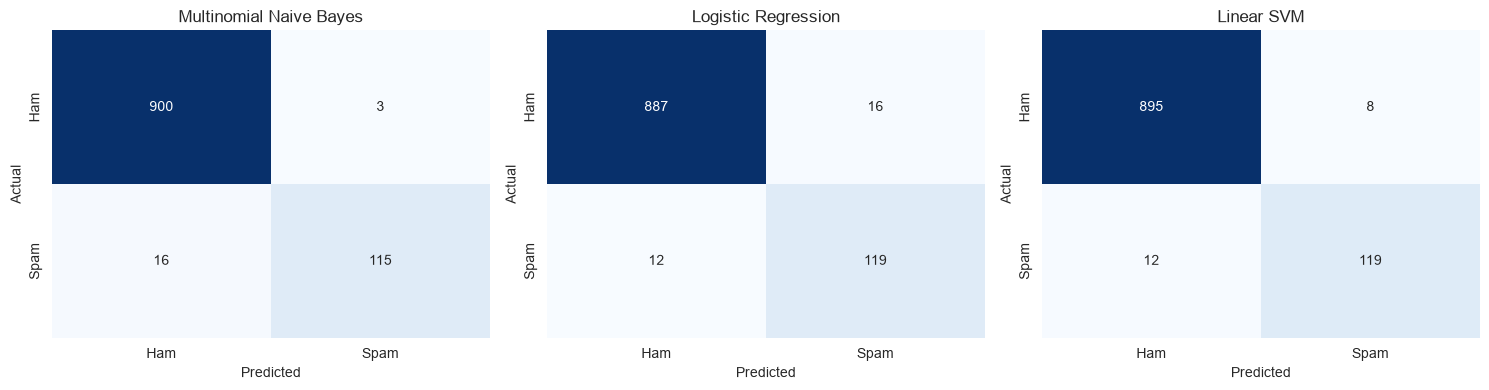

In [13]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, len(predictions), figsize=(15, 4))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    ax.set_title(name)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

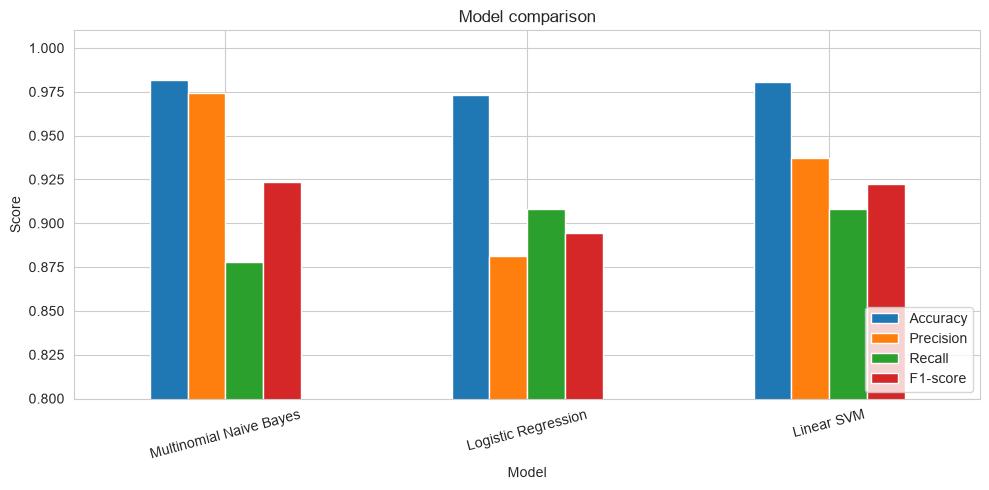

In [14]:
# Model comparison chart
results_df.plot(kind='bar', figsize=(10, 5), ylim=(0.8, 1.01))
plt.title('Model comparison'); plt.ylabel('Score'); plt.xticks(rotation=15)
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

**Reading the confusion matrix:** rows = actual class, columns = predicted class.
- Top-left (TN): ham correctly kept in the inbox
- Top-right (FP): ham wrongly flagged as spam (a legitimate message lost)
- Bottom-left (FN): spam that slipped through to the inbox
- Bottom-right (TP): spam correctly caught

## 9. Discussion: Why is recall important for spam detection?

**Recall = TP / (TP + FN)**: of all the messages that are *actually spam*, what fraction did the model catch?

- A low recall means many spam messages (**false negatives**) reach the inbox. Those can be phishing links, scams or malware, so each miss can cause real harm (stolen credentials, financial fraud).
- High recall means the filter does its main job: catching as much spam as possible.

**But recall alone is not enough.** A model that labels *everything* as spam has 100% recall but is useless, because it blocks genuine mail. Wrongly blocking an important email (a **false positive**) is also costly, e.g. a job offer or bank alert ending up in the spam folder. That is why **precision** matters too, and why we use the **F1-score** (the harmonic mean of precision and recall) to balance the two.

In practice, spam filters aim for high recall while keeping precision very high, so spam is caught without hiding legitimate messages.

**Comparing our models:** a model with higher precision but lower recall lets more spam slip through, while a model with higher recall catches more spam but may flag more genuine messages. Compare the metrics table in Section 8 to see this trade-off for each model.


## 10. (Bonus) WordCloud visualisations

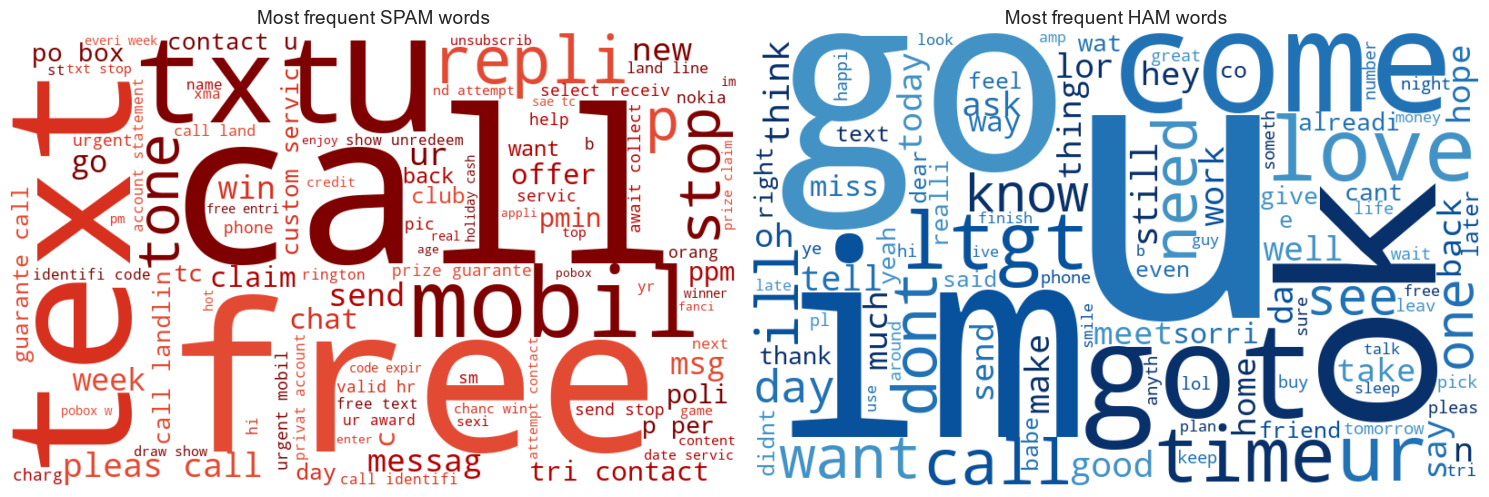

In [15]:
from wordcloud import WordCloud
from matplotlib.colors import ListedColormap

# Dark shades so even the most frequent words stay readable on a white background
spam_cmap = ListedColormap(['#7f0000', '#b30000', '#d7301f', '#e34a33'])
ham_cmap = ListedColormap(['#08306b', '#08519c', '#2171b5', '#4292c6'])

spam_text = ' '.join(df[df['label'] == 'spam']['clean_message'])
ham_text = ' '.join(df[df['label'] == 'ham']['clean_message'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, text, title, cmap in zip(
        axes, [spam_text, ham_text],
        ['Most frequent SPAM words', 'Most frequent HAM words'],
        [spam_cmap, ham_cmap]):
    wc = WordCloud(width=800, height=500, background_color='white',
                   colormap=cmap, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=14)
    ax.axis('off')
plt.tight_layout(); plt.show()

**Observation:** Spam is dominated by words like *free, call, txt, claim, prize, win, urgent, mobil*, which push the reader to act or promise rewards. Ham words are everyday conversational terms.

## 11. Top spam-indicating words (from the model)

In [16]:
# Words with the largest Logistic Regression coefficients push a message towards spam
lr = models['Logistic Regression']
feature_names = np.array(tfidf.get_feature_names_out())
top_idx = np.argsort(lr.coef_[0])[-15:][::-1]
pd.DataFrame({'Word': feature_names[top_idx], 'Weight': lr.coef_[0][top_idx].round(3)})

,Word,Weight
0,txt,5.013
1,call,4.367
2,free,4.061
3,text,4.001
4,mobil,3.973
5,repli,3.971
6,claim,3.565
7,prize,3.243
8,stop,3.162
9,servic,2.936


## 12. Try it on new messages

In [17]:
best_model = models['Multinomial Naive Bayes']   # change to any trained model

def predict_message(text, model=best_model):
    vec = tfidf.transform([preprocess_text(text)])
    return 'SPAM' if model.predict(vec)[0] == 1 else 'HAM'

tests = [
    "Congratulations! You have won a free iPhone. Click the link to claim your prize now!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT! Your account has been selected for a cash reward. Call 09061701461 now",
    "Can you send me the notes from today's lecture?",
]
for t in tests:
    print(f'[{predict_message(t)}] {t}')

[SPAM] Congratulations! You have won a free iPhone. Click the link to claim your prize now!
[HAM] Hey, are we still meeting for lunch tomorrow?
[SPAM] URGENT! Your account has been selected for a cash reward. Call 09061701461 now
[HAM] Can you send me the notes from today's lecture?


## 13. Conclusion
- Cleaned the text (lowercase, punctuation/stopword removal, stemming) and converted it to numeric features using TF-IDF.
- Trained Multinomial Naive Bayes, Logistic Regression and Linear SVM; all reach high accuracy, with strong precision and recall on spam.
- Because the data is imbalanced, precision, recall and F1 give a more honest picture than accuracy alone.
- **Possible improvements:** cross-validation, hyperparameter tuning (`GridSearchCV`), lemmatization instead of stemming, and testing on a real email dataset.